# Common analytical features
## z-score

$z=\frac{x-\mu}{\sigma}$

Example: income seems to be related to highest degree completed. It is unfair to compare people's income with people with different education attainment. We can compute income's z-score by education so we can compare them with their peers.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# read the data
nls97 = pd.read_csv("../05-data_cleaning/data/nls97.csv")

nls97

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
1,100139,Male,9,1983,12.0,Married,2.0,0.0,120000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
2,100284,Male,11,1984,7.0,Never-married,1.0,0.0,58000.0,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
3,100292,Male,4,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,NaN,NaN,NaN,NaN
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8979,999291,Female,4,1981,16.0,Married,NaN,NaN,35000.0,7 to 9 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
8980,999406,Male,7,1982,14.0,Never-married,NaN,NaN,116000.0,4 to 6 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
8981,999543,Female,8,1984,12.0,Divorced,2.0,0.0,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
8982,999698,Female,5,1983,12.0,Never-married,5.0,0.0,NaN,4 to 6 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled


In [15]:
nls97['highestdegree'].value_counts()

highestdegree
2. High School     3667
4. Bachelors       1673
1. GED             1146
0. None             953
3. Associates       737
5. Masters          603
7. Professional     120
6. PhD               54
Name: count, dtype: int64

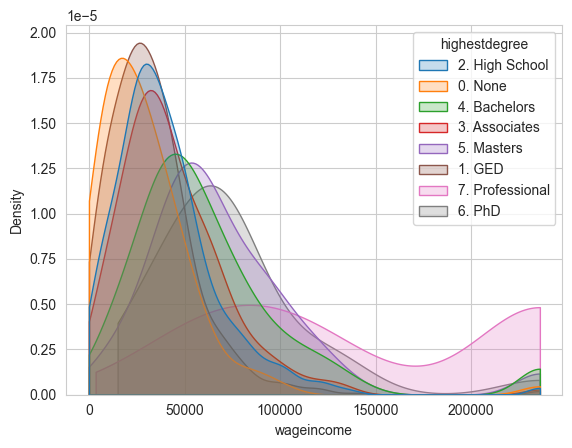

In [19]:
sns.kdeplot(data=nls97, x="wageincome", hue='highestdegree', fill=True, cut=0, common_norm=False)
plt.show()

In [22]:
nls97['wageincome_z_score'] = (nls97['wageincome'] - nls97['wageincome'].mean()) / nls97['wageincome'].std()
nls97['wageincome_z_score_by_education'] = nls97.groupby("highestdegree")['wageincome'].transform(lambda x: (x - x.mean()) / x.std())

<Axes: xlabel='wageincome_z_score_by_education', ylabel='Density'>

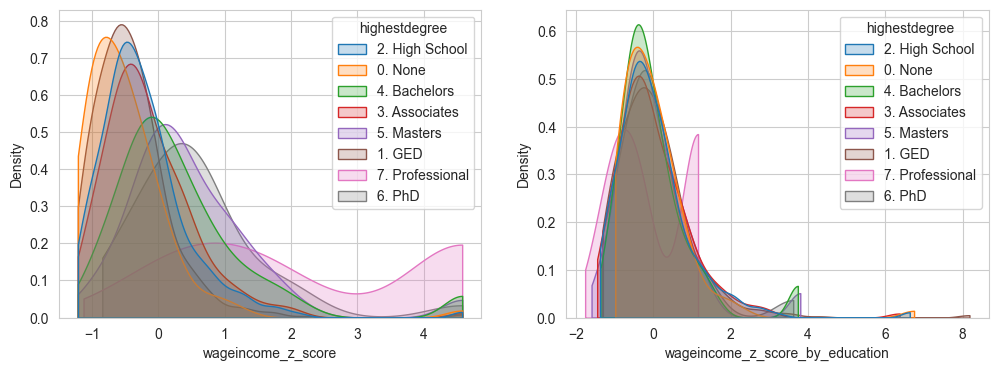

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.kdeplot(data=nls97, x="wageincome_z_score", hue='highestdegree', fill=True, cut=0, common_norm=False, ax=axes[0])

sns.kdeplot(data=nls97, x="wageincome_z_score_by_education", hue='highestdegree', fill=True, cut=0, common_norm=False, ax=axes[1])


### Interpret z-score

In [30]:
nls97['high_wages'] = (nls97['wageincome_z_score'] > 3).astype(int)
nls97['high_wages_by_education'] = (nls97['wageincome_z_score_by_education'] > 3).astype(int)

In [31]:
nls97[(nls97['high_wages']==1) & (nls97['high_wages_by_education']==0)][['personid','gender','highestdegree','wageincome']]

,personid,gender,highestdegree,wageincome
343,131858,Male,7. Professional,235884.0
651,164058,Male,7. Professional,235884.0
767,175442,Male,7. Professional,235884.0
1574,253373,Male,7. Professional,235884.0
1676,264469,Male,7. Professional,235884.0
1714,268217,Male,7. Professional,235884.0
2122,308385,Female,7. Professional,235884.0
2143,310473,Male,7. Professional,235884.0
2278,325632,Female,7. Professional,235884.0
2894,387118,Male,7. Professional,235884.0


## Min-max scaling


In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../07-Data_visualization/data/stony_brook_daily_temperature_2025.csv")

# Convert Celsius → Fahrenheit
df["temp_F"] = df["average_temperature"] * 9/5 + 32
df['date'] = pd.to_datetime('2025-' + df['month'].astype(str) + '-' + df['day'].astype(str))

df

,month,day,average_temperature,temp_F,date
0,1,1,7.5,45.50,2025-01-01
1,1,2,3.3,37.94,2025-01-02
2,1,3,0.6,33.08,2025-01-03
3,1,4,-1.5,29.30,2025-01-04
4,1,5,-2.3,27.86,2025-01-05
...,...,...,...,...,...
360,12,27,-3.3,26.06,2025-12-27
361,12,28,-2.8,26.96,2025-12-28
362,12,29,5.8,42.44,2025-12-29
363,12,30,-1.2,29.84,2025-12-30


In [38]:
min_val = df["temp_F"].min()
max_val = df["temp_F"].max()

df["temp_scaled"] = (df["temp_F"] - min_val) / (max_val - min_val)

df[['date','temp_F','temp_scaled']]

,date,temp_F,temp_scaled
0,2025-01-01,45.50,0.4200
1,2025-01-02,37.94,0.3150
2,2025-01-03,33.08,0.2475
3,2025-01-04,29.30,0.1950
4,2025-01-05,27.86,0.1750
...,...,...,...
360,2025-12-27,26.06,0.1500
361,2025-12-28,26.96,0.1625
362,2025-12-29,42.44,0.3775
363,2025-12-30,29.84,0.2025


<Axes: xlabel='temp_scaled', ylabel='Density'>

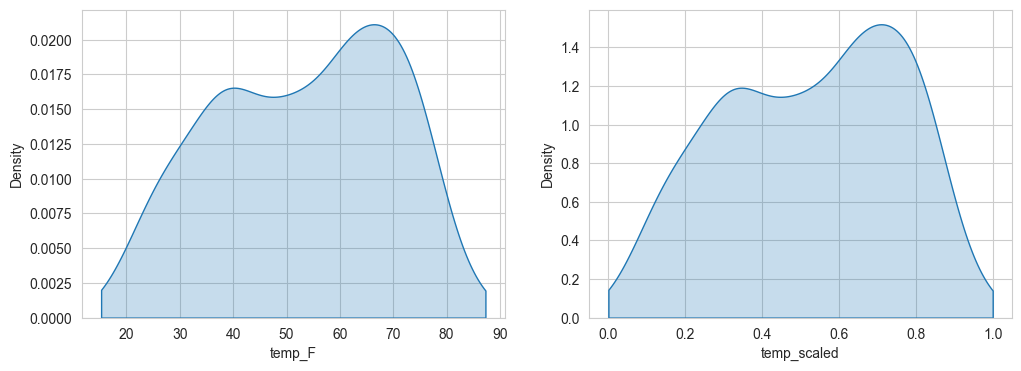

In [43]:
# observe the following distributions. Their shape look the same, but the scales (x-axis) are different.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.kdeplot(data=df, x="temp_F", fill=True, clip=(min_val, max_val), ax=axes[0])

sns.kdeplot(data=df, x="temp_scaled", fill=True, clip=(0, 1), ax=axes[1])


Why It’s Useful?
Add another variable (different scale), and compare before vs after

In [45]:
df["humidity"] = np.random.uniform(20, 100, df.shape[0])

# Scale humidity too
df["humidity_scaled"] = (
    (df["humidity"] - df["humidity"].min()) /
    (df["humidity"].max() - df["humidity"].min())
)

df[['date','temp_F','humidity','temp_scaled','humidity_scaled']]

,date,temp_F,humidity,temp_scaled,humidity_scaled
0,2025-01-01,45.50,53.864857,0.4200,0.423280
1,2025-01-02,37.94,21.989383,0.3150,0.024756
2,2025-01-03,33.08,96.664925,0.2475,0.958389
3,2025-01-04,29.30,32.539475,0.1950,0.156659
4,2025-01-05,27.86,61.885183,0.1750,0.523554
...,...,...,...,...,...
360,2025-12-27,26.06,51.075016,0.1500,0.388400
361,2025-12-28,26.96,43.658770,0.1625,0.295678
362,2025-12-29,42.44,74.497800,0.3775,0.681244
363,2025-12-30,29.84,86.646086,0.2025,0.833128


<Axes: xlabel='value', ylabel='Density'>

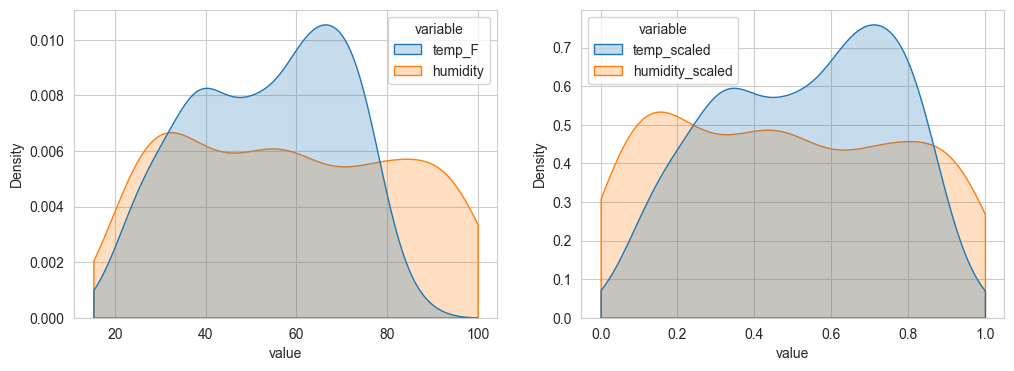

In [51]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.kdeplot(data=df.melt(id_vars='date', value_vars=['temp_F', 'humidity']), x='value', hue='variable', fill=True, clip=(min([df['temp_F'].min(), df['humidity'].min()]), max([df['temp_F'].max(), df['humidity'].max()])), ax=axes[0])

sns.kdeplot(data=df.melt(id_vars='date', value_vars=['temp_scaled', 'humidity_scaled']), x='value', hue='variable', clip=(0, 1),fill=True, ax=axes[1])
